In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("../data/raw/hotels_users_ratings.csv")

In [7]:
print(df.shape)
df.head()

(38801, 9)


,URL Hotel,Location,HotelID,Name Hotel,Descriptions,Address,UserID,User,Rating
0,https://www.booking.com/hotel/vn/dalat-wind.vi...,Đà Lạt,4064,Dalat Wind Deluxe Hotel,"Tọa lạc tại thành phố Đà Lạt, cách Hồ Xuân Hươ...","Lot R2 03-04. Golf Valley, Ward 2, Đà Lạt, Viê...",1187,Thảo,6
1,https://www.booking.com/hotel/vn/dalat-wind.vi...,Đà Lạt,4064,Dalat Wind Deluxe Hotel,"Tọa lạc tại thành phố Đà Lạt, cách Hồ Xuân Hươ...","Lot R2 03-04. Golf Valley, Ward 2, Đà Lạt, Viê...",1284,Tran,5
2,https://www.booking.com/hotel/vn/dalat-wind.vi...,Đà Lạt,4064,Dalat Wind Deluxe Hotel,"Tọa lạc tại thành phố Đà Lạt, cách Hồ Xuân Hươ...","Lot R2 03-04. Golf Valley, Ward 2, Đà Lạt, Viê...",5866,Tho,6
3,https://www.booking.com/hotel/vn/dalat-wind.vi...,Đà Lạt,4064,Dalat Wind Deluxe Hotel,"Tọa lạc tại thành phố Đà Lạt, cách Hồ Xuân Hươ...","Lot R2 03-04. Golf Valley, Ward 2, Đà Lạt, Viê...",3033,Tuan,9
4,https://www.booking.com/hotel/vn/dalat-wind.vi...,Đà Lạt,4064,Dalat Wind Deluxe Hotel,"Tọa lạc tại thành phố Đà Lạt, cách Hồ Xuân Hươ...","Lot R2 03-04. Golf Valley, Ward 2, Đà Lạt, Viê...",1406,Phan,7


check thieu du lieu

In [18]:
df.isnull().sum()

URL Hotel       0
Location        0
HotelID         0
Name Hotel      0
Descriptions    0
Address         0
UserID          0
User            0
Rating          0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38801 entries, 0 to 38800
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   URL Hotel     38801 non-null  object
 1   Location      38801 non-null  object
 2   HotelID       38801 non-null  int64 
 3   Name Hotel    38801 non-null  object
 4   Descriptions  38801 non-null  object
 5   Address       38801 non-null  object
 6   UserID        38801 non-null  int64 
 7   User          38801 non-null  object
 8   Rating        38801 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 2.7+ MB


check duplicate

In [11]:
df.duplicated().sum()

np.int64(298)

so luong user va hotel

In [12]:
print("number of users:", df["UserID"].nunique())
print("number of hotels:", df["HotelID"].nunique())

number of users: 6471
number of hotels: 4506


Dataset gồm ~38k ratings

~6.4k users

~4.5k hotels

Rating nằm trong khoảng 4–10

Mean rating khá cao → thiên lệch tích cực

xu ly duplicate

In [14]:
df = df.drop_duplicates()
print("duplicates sau khi xoa:", df.duplicated())
print ('Shape moi:', df.shape)

duplicates sau khi xoa: 0        False
1        False
2        False
3        False
4        False
         ...  
38796    False
38797    False
38798    False
38799    False
38800    False
Length: 38503, dtype: bool
Shape moi: (38503, 9)


phan phoi rating

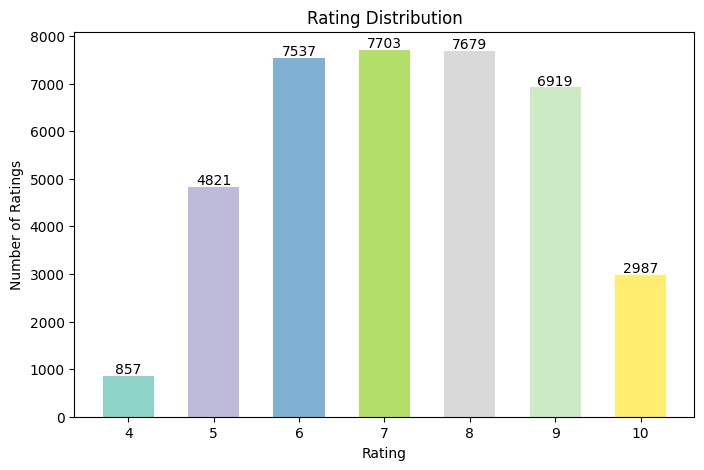

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Đếm số lượng từng rating
rating_counts = df['Rating'].value_counts().sort_index()

# Tạo danh sách màu
colors = plt.cm.Set3(np.linspace(0, 1, len(rating_counts)))

plt.figure(figsize=(8,5))

plt.bar(
    rating_counts.index,
    rating_counts.values,
    color=colors,
    width=0.6   # tạo khoảng cách giữa các cột
)

for i, v in enumerate(rating_counts.values):
    plt.text(rating_counts.index[i], v + 50, str(v), ha = 'center')
    
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Rating Distribution")
plt.xticks(rating_counts.index)

plt.show()

Rating phân bố chủ yếu từ 6–9.

Không có rating thấp (1–3).

Dataset có positive bias.

Điều này có thể ảnh hưởng đến khả năng phân biệt của model.

In [19]:
#tính sparsity
num_users = df['UserID'].nunique()
num_hotels = df['HotelID'].nunique()
num_ratings = len(df)

sparsity = 1 - (num_ratings / (num_hotels * num_users))

sparsity

0.9986795195307165

phan tich cold start

In [20]:
#rating per user
user_counts = df['UserID'].value_counts()
user_counts.describe()

count    6471.000000
mean        5.950085
std        28.776947
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       803.000000
Name: count, dtype: float64

In [21]:
#rating per hotel
hotel_counts = df['HotelID'].value_counts()
hotel_counts.describe()

count    4506.000000
mean        8.544829
std         4.912044
min         1.000000
25%         5.000000
50%        10.000000
75%        10.000000
max        30.000000
Name: count, dtype: float64

In [22]:
# Filter users with >= 3 ratings
user_counts = df['UserID'].value_counts()
active_users = user_counts[user_counts >= 3].index
df = df[df['UserID'].isin(active_users)]

# Filter hotels with >= 3 ratings
hotel_counts = df['HotelID'].value_counts()
active_hotels = hotel_counts[hotel_counts >= 3].index
df = df[df['HotelID'].isin(active_hotels)]

print("New shape:", df.shape)

New shape: (31345, 9)


Nhận xét:

Sau khi phân tích dữ liệu, nhận thấy:

Dataset có 298 bản ghi trùng lặp, đã được loại bỏ.

Ma trận User–Hotel có độ thưa rất cao (~99.87%), đây là đặc trưng phổ biến của hệ khuyến nghị.

50% người dùng chỉ đánh giá 1 khách sạn và 75% đánh giá không quá 2 khách sạn, cho thấy vấn đề cold-start user rất nghiêm trọng.

Một số khách sạn chỉ có 1 lượt đánh giá, có thể gây khó khăn cho việc tính toán độ tương đồng.

Vì vậy, đã thực hiện:

Loại bỏ các user có ít hơn 3 lượt đánh giá.

Loại bỏ các hotel có ít hơn 3 lượt đánh giá.

Việc lọc này giúp:

Giảm sparsity

Cải thiện chất lượng tính toán độ tương đồng

Giúp mô hình Collaborative Filtering hoạt động ổn định hơn